In [92]:
from dotenv import load_dotenv
import os

load_dotenv()

os.environ["GEMINI_API_KEY"] = os.getenv("GEMINI_API_KEY")
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_ENDPOINT"] = "https://api.smith.langchain.com"
os.environ["LANGCHAIN_API_KEY"] = os.getenv("LANGCHAIN_API_KEY")
os.environ["LANGCHAIN_PROJECT"] = "Proyecto Inicial"
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

# Ejemplo de Supervisor

In [93]:
import operator
from typing import Annotated, TypedDict, Literal

from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.tools import tool
from langgraph.graph import StateGraph, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode

In [ ]:
@tool
def get_crypto_price(crypto: str) -> str:
    """Obtiene el precio actual de una criptomoneda."""
    # Aquí iría la lógica para obtener el precio de la criptomoneda
    return f"El precio actual de {crypto} es $USD4000.00"

@tool
def get_day() -> str:
    """Obtiene la fecha del día actual en formato datetime en formato YYYY-MM-DD."""
    # Aquí iría la lógica para obtener la fecha actual
    import datetime
    return datetime.datetime.now().strftime("%Y-%m-%d")

tools = [get_crypto_price, get_day]
tool_nodes = ToolNode(tools=tools)

In [95]:
from langchain_core.messages import BaseMessage
from typing import Sequence

class AgentState(TypedDict):
    # The annotation here is used to add the messages to the state graph
    messages: Annotated[Sequence[BaseMessage], add_messages]
    # The 'next' field is used to indicate the next node in the graph
    next: str

### Create Agents

In [96]:
from langchain_tavily import TavilySearch

web_search = TavilySearch(max_results=3)

In [ ]:
from langchain.agents import create_agent
from langchain_groq import ChatGroq

llm_research = ChatGroq(model="llama-3.3-70b-versatile", temperature=0)

researcher_agent = create_agent(
    model=llm_research,
    tools=[web_search],
    system_prompt=(
        "You are a strict research agent.\n\n"
        "INSTRUCTIONS:\n"
        "- Your ONLY job is to search for raw information and facts.\n"
        "- If the user's prompt includes ANY math or calculations, IGNORE the math completely.\n"
        "- Return ONLY the exact data you found (e.g. 'The population is 45,000,000'). Do not perform any operations on the numbers.\n"
        "- Always respond back directly to the supervisor. DO NOT try to transfer work to other agents."
    ),
    name="research_agent"
)

In [98]:
from langchain_core.tools import tool

@tool
def add(a: float, b: float):
    """Add two numbers."""
    return a + b

@tool
def multiply(a: float, b: float):
    """Multiply two numbers."""
    return a * b

@tool
def divide(a: float, b: float):
    """Divide two numbers."""
    return a / b

tools = [add, multiply, divide]

llm_math = ChatGroq(model="llama-3.3-70b-versatile", temperature=0)

math_agent = create_agent(
    model=llm_math,  
    tools=tools,
    system_prompt=(
        "You are a math agent.\n\n"
        "INSTRUCTIONS:\n"
        "- Assist ONLY with math-related tasks\n"
        "- After you're done with your tasks, respond to the supervisor directly\n"
        "- Respond ONLY with the results of your work, do NOT include ANY other text."
    ),
    name="math_agent",
)

### Create Supervisor

In [99]:
from langgraph_supervisor import create_supervisor
from langchain.chat_models import init_chat_model

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0.0, max_tokens=2048)

supervisor = create_supervisor(
    model=llm,
    agents=[researcher_agent, math_agent],
    prompt=(
        "You are a supervisor managing two agents:\n"
        "- a research agent. Assign research-related tasks to this agent\n"
        "- a math agent. Assign math-related tasks to this agent\n"
        "Assign work to one agent at a time, do not call agents in parallel.\n"
        "Do not do any work yourself."
    ),
    add_handoff_back_messages=True,
    output_mode="full_history",
).compile()

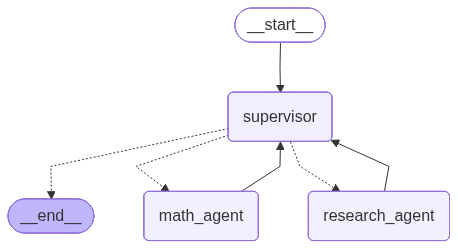

In [100]:
from IPython.display import display, Image

display(Image(supervisor.get_graph().draw_mermaid_png()))

In [101]:
from langchain_core.messages import convert_to_messages


def pretty_print_message(message, indent=False):
    pretty_message = message.pretty_repr(html=True)
    if not indent:
        print(pretty_message)
        return

    indented = "\n".join("\t" + c for c in pretty_message.split("\n"))
    print(indented)


def pretty_print_messages(update, last_message=False):
    is_subgraph = False
    if isinstance(update, tuple):
        ns, update = update
        # skip parent graph updates in the printouts
        if len(ns) == 0:
            return

        graph_id = ns[-1].split(":")[0]
        print(f"Update from subgraph {graph_id}:")
        print("\n")
        is_subgraph = True

    for node_name, node_update in update.items():
        update_label = f"Update from node {node_name}:"
        if is_subgraph:
            update_label = "\t" + update_label

        print(update_label)
        print("\n")

        messages = convert_to_messages(node_update["messages"])
        if last_message:
            messages = messages[-1:]

        for m in messages:
            pretty_print_message(m, indent=is_subgraph)
        print("\n")

In [102]:
for chunk in supervisor.stream(
    {
        "messages": [
            {
                "role": "user",
                "content": "Decime cuanto es la cantidad de habitantes en Argentina, y luego didivila por 2.",
            }
        ]
    },
):
    pretty_print_messages(chunk, last_message=True)

final_message_history = chunk["supervisor"]["messages"]

Update from node supervisor:


================================= Tool Message =================================
Name: transfer_to_research_agent

Successfully transferred to research_agent




BadRequestError: Error code: 400 - {'error': {'message': "tool call validation failed: attempted to call tool 'transfer_to_math_agent' which was not in request.tools", 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': '<function=transfer_to_math_agent>{}</function>'}}